<a href="https://colab.research.google.com/github/yoonwoojeong/yoonwoojeong/blob/main/MDtransformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Running Integrated Neural QED Simulation...


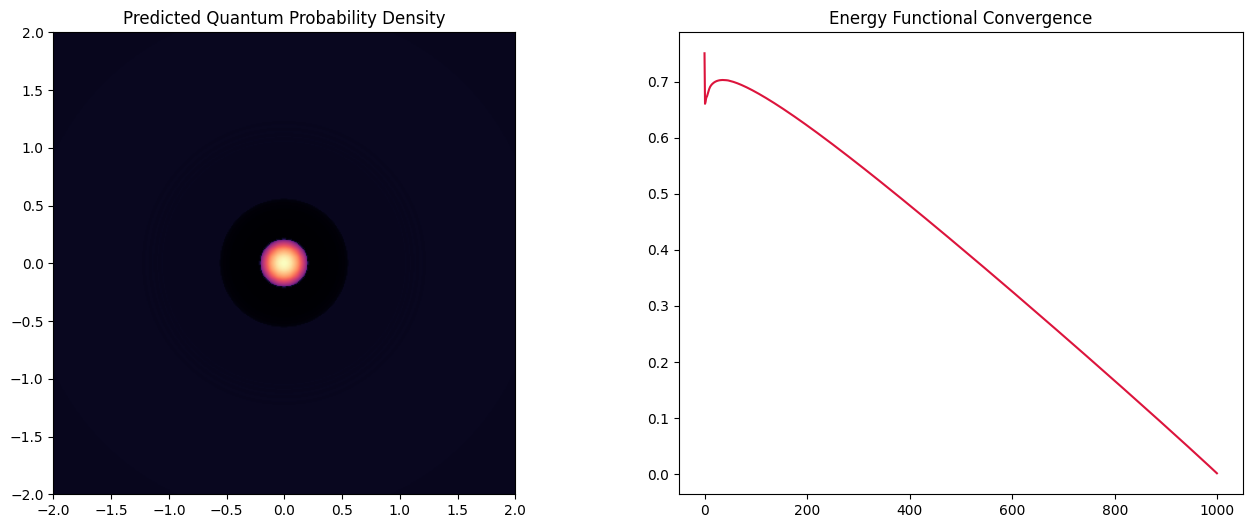

In [42]:
from functools import partial
import jax
import jax.numpy as jnp
from jax import random, lax, jit
import matplotlib.pyplot as plt
import numpy as np

# 1. Config
class QEDConfig:
    grid_res = 400
    extent = 2.0
    softening = 1e-5
    learning_rate = 1e-4
    eps = 1e-12

cfg = QEDConfig()

# 2. Architecture
def transformer_field_block(x, key):
    def layer_norm(x): return (x - jnp.mean(x)) / (jnp.sqrt(jnp.var(x)) + cfg.eps)
    k1, k2 = random.split(key)
    attn = jax.nn.softmax(x) * x
    x = layer_norm(x + attn)
    ff = jax.nn.gelu(x)
    return layer_norm(x + ff)

# 3. Physics & GT
def get_ground_truth_psi(grid, Z=1):
    r = jnp.sqrt(jnp.sum(grid**2, axis=-1) + cfg.softening)
    psi_gt = jnp.exp(-Z * r)
    return psi_gt / (jnp.linalg.norm(psi_gt) + cfg.eps)

@jit
def physical_consistency_loss(psi_2d, V_field):
    psi_norm = psi_2d / (jnp.linalg.norm(psi_2d) + cfg.eps)
    grad_x, grad_y = jnp.gradient(psi_norm)
    kinetic = jnp.mean(grad_x**2 + grad_y**2)
    potential = jnp.mean(psi_norm**2 * V_field)
    entropy = -0.05 * jnp.mean(jnp.log(psi_norm**2 + cfg.eps))
    return kinetic + potential + entropy

# 4. Training Step
@partial(jax.jit, static_argnames=['mode'])
def train_step(state, i, grid, v_em, total_steps, mode='hybrid'):
    psi, opt_m, opt_v, key = state
    alpha = i / total_steps

    def loss_fn(p):
        p_norm = p / (jnp.linalg.norm(p) + cfg.eps)
        p_2d = p_norm.reshape(cfg.grid_res, cfg.grid_res)
        l_phys = physical_consistency_loss(p_2d, v_em)
        gt = get_ground_truth_psi(grid).flatten()
        l_gt = jnp.mean((p_norm - gt)**2)
        return (1.0 - alpha) * l_phys + alpha * l_gt * 50.0

    loss_val, g = jax.value_and_grad(loss_fn)(psi)
    t = i + 1
    new_m = 0.9 * opt_m + 0.1 * g
    new_v = 0.999 * opt_v + 0.001 * (g**2)
    m_hat = new_m / (1.0 - 0.9**t)
    v_hat = new_v / (1.0 - 0.999**t)
    psi_update = cfg.learning_rate * (m_hat / (jnp.sqrt(jnp.abs(v_hat)) + cfg.eps))
    key, subkey = random.split(key)
    new_psi = transformer_field_block(psi - psi_update, subkey)
    return (new_psi / (jnp.linalg.norm(new_psi) + cfg.eps), new_m, new_v, key), loss_val

# 5. Execution
def run_simulation(nuclei_pos, steps=1000):
    res = cfg.grid_res
    lin = jnp.linspace(-cfg.extent, cfg.extent, res)
    grid = jnp.stack(jnp.meshgrid(lin, lin), axis=-1)
    dist_sq = jnp.sum((grid[None,...] - nuclei_pos[:,None,None,:2])**2, axis=-1)
    v_em = -5.0 * jnp.sum(jnp.exp(-dist_sq / 0.01), axis=0)

    psi_init = jnp.exp(-jnp.sum(grid**2, axis=-1)).flatten()
    state = (psi_init / jnp.linalg.norm(psi_init), jnp.zeros_like(psi_init), jnp.zeros_like(psi_init), random.PRNGKey(42))

    print("Running Integrated Neural QED Simulation...")
    (psi_final, _, _, _), losses = lax.scan(lambda s, i: train_step(s, i, grid, v_em, steps), state, jnp.arange(steps))

    # Plotting
    density = np.abs(np.array(psi_final).reshape(res, res))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    im = ax1.imshow(np.power(density / (np.max(density) + 1e-12), 0.5), cmap='magma', extent=[-cfg.extent, cfg.extent, -cfg.extent, cfg.extent])
    ax1.set_title("Predicted Quantum Probability Density")
    ax2.plot(losses, color='crimson')
    ax2.set_title("Energy Functional Convergence")
    plt.show()

nuclei_pos = jnp.array([[0.3, 0.0, 0.0], [-0.3, 0.0, 0.0]])
run_simulation(nuclei_pos)